In [0]:
# ============================================================
# Import Libraries
# ============================================================

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
import pandas as pd

In [0]:
# ============================================================
# Project Configuration
# ============================================================

BASE_PATH = "/Volumes/project/default/data"

CLEAN_DATASET_PATH = f"/Volumes/project/default/data/clean/cleaned_merged_dataset"

print(CLEAN_DATASET_PATH)

/Volumes/project/default/data/clean/cleaned_merged_dataset


In [0]:
# ============================================================
# Load Clean Dataset
# ============================================================

merged_df = spark.read.parquet(CLEAN_DATASET_PATH)

print(f"Total Records : {merged_df.count():,}")
print(f"Total Columns : {len(merged_df.columns)}")

display(merged_df.limit(5))

Total Records : 2,128,605
Total Columns : 27


parent_asin,asin,user_id,review_rating,review_title,review_text,helpful_vote,verified_purchase,review_images,product_title,average_rating,rating_number,price,store,main_category,categories,features,description,details,product_images,videos,review_timestamp,year,month,day,quarter,week
B09Z2CBDDP,B09Z2DQ5VH,AFTQN4MTJHHVFM4FEXY5KT76OY4A,5.0,Nice organizer!,"We go through eggs like crazy, so I am loving this egg storage system. It saves a lot of space! I especially like that I can see exactly how many eggs we have on hand!!! The clear plastic is thick than I expected and well made. I also like that other items in the fridge can be set on top and not worry about them getting crushed. I expect this egg storage system to last us a long time and we've very pleased with it.",0,false,List(),"Egg Storage Container, Realife Automatic Rolling Egg Organizer Clear Plastic Holder for Refrigerator, 1 Layer",4.3,79,12.99,realife,Tools & Home Improvement,"List(Appliances, Parts & Accessories, Refrigerator Parts & Accessories, Egg Trays)","List([Auto Rolling Egg Storage]: The egg storage organizer for refrigerator adopts 7° slope design which makes eggs roll down automatically to the front place, easy to take out the egg from the holder without opening the lid., [ Stackable Layer Design]: Our egg container is designed with stackable layers which fixed with a card slot. Each layer can store 18 eggs keeping the refrigerator in order, no mess anymore. Semi-enclosed design can provide convenience for your life as well as good ventilation., [Transparent Egg Container ]: The automatic rolling egg organizer with lid is clearly visible adopting a transparent body which is easy to see and convenient for timely replenishment. The detachable cover is designed to load eggs conveniently. Storage grooves of the lid top can hold up to extra 9 eggs., [Food-Grade Plastic]: This egg storage container uses premium PET plastic, BPA free, durable and easy to clean. Low temperature resistant, suitable to keep in the fridge., [ Size for Wide Application ]:11""L×9""W×2.8""H one layer egg storage holder is not only perfect for refrigerator, but also for kitchen, restaurant, cabinets, table, countertop and racks.)",List(),"Map(Package Dimensions -> 11.97 x 9.57 x 3.27 inches, Pattern -> Single layer, Number of Pieces -> 1, Best Sellers Rank -> {""Tools & Home Improvement"": 157091, ""Refrigerator Egg Trays"": 216}, Size -> S, Batteries Required? -> No, Material -> Polypropylene, Plastic, Shape -> Rectangular, Manufacturer -> realife, Item Weight -> 1 pounds, Date First Available -> April 28, 2022, Room Type -> Kitchen, Handle Material -> Plastic, Brand -> Realife, Country of Origin -> China, Color -> Transparent, Batteries Included? -> No)","List(Map(thumb -> https://m.media-amazon.com/images/I/419J2mecTFL._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/419J2mecTFL._AC_.jpg, variant -> MAIN, hi_res -> https://m.media-amazon.com/images/I/71fa74TCNpL._AC_SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/41cXAzPkPhL._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/41cXAzPkPhL._AC_.jpg, variant -> PT01, hi_res -> https://m.media-amazon.com/images/I/71Qgd+EEdVL._AC_SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/41xzKnbOCGL._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/41xzKnbOCGL._AC_.jpg, variant -> PT02, hi_res -> https://m.media-amazon.com/images/I/71xWYH-S6SL._AC_SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/31286KypXzL._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/31286KypXzL._AC_.jpg, variant -> PT03, hi_res -> https://m.media-amazon.com/images/I/61KQhWPfsZL._AC_SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/41eUiwBJTSL._AC_US75_.jpg, large -> https://m.media-amazon.com/images/I/41eUiwBJTSL._AC_.jpg, variant -> PT04, hi_res -> https://m.media-amazon.com/images/I/71OSxGYZnHL._AC_SL1500_.jpg), Map(thumb -> https://m.media-amazon.com/images/I/41hatuFxCLL._AC_US75

In [0]:
# ============================================================
# Dataset Summary
# ============================================================

summary = [

    ("Rows", merged_df.count()),
    ("Columns", len(merged_df.columns)),
    ("Unique Products", merged_df.select("parent_asin").distinct().count()),
    ("Unique Users", merged_df.select("user_id").distinct().count())

]

summary_df = spark.createDataFrame(
    summary,
    ["Metric", "Value"]
)

display(summary_df)

Metric,Value
Rows,2128605
Columns,27
Unique Products,94319
Unique Users,1755732


In [0]:
# ============================================================
# Dataset Overview
# ============================================================

summary = [

    ("Total Reviews", merged_df.count()),

    ("Unique Products",
     merged_df.select("parent_asin").distinct().count()),

    ("Unique Users",
     merged_df.select("user_id").distinct().count()),

    ("Unique Stores",
     merged_df.select("store").distinct().count()),

    ("Main Categories",
     merged_df.select("main_category").distinct().count())

]

summary_df = spark.createDataFrame(
    summary,
    ["Metric", "Value"]
)

display(summary_df)

Metric,Value
Total Reviews,2128605
Unique Products,94319
Unique Users,1755732
Unique Stores,13166
Main Categories,31


In [0]:
# ============================================================
# Review Rating Distribution
# ============================================================

rating_distribution = (

    merged_df
    .groupBy("review_rating")
    .count()
    .orderBy("review_rating")

)

rating_pd = rating_distribution.toPandas()

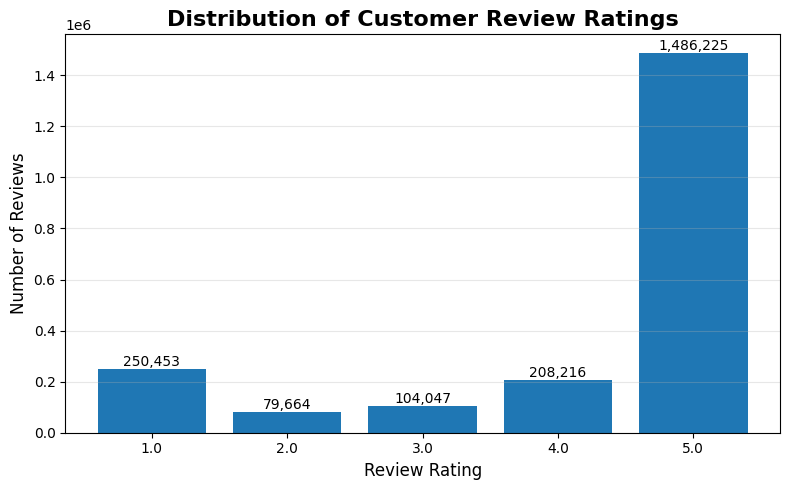

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    rating_pd["review_rating"].astype(str),
    rating_pd["count"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Distribution of Customer Review Ratings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Review Rating", fontsize=12)

plt.ylabel("Number of Reviews", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Verified Purchase Distribution
# ============================================================

verified_df = (

    merged_df

    .groupBy("verified_purchase")

    .count()

    .orderBy("verified_purchase")

)

verified_pd = verified_df.toPandas()

verified_pd

,verified_purchase,count
0,False,88541
1,True,2040064


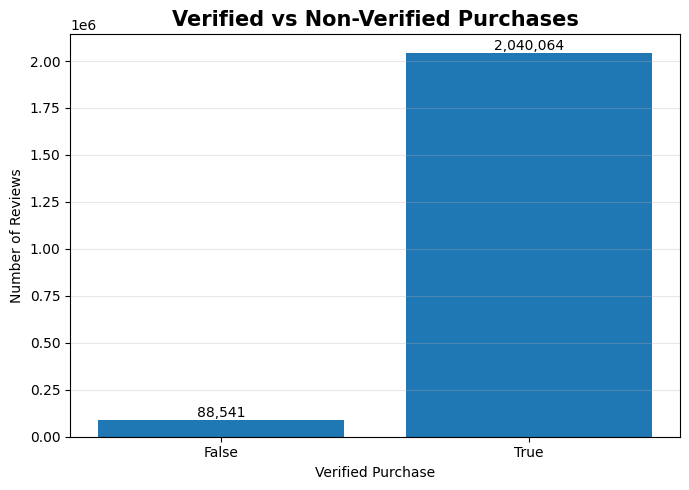

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

bars = plt.bar(

    verified_pd["verified_purchase"].astype(str),

    verified_pd["count"]

)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height,

        f"{height:,}",

        ha="center",

        va="bottom",

        fontsize=10

    )

plt.title(

    "Verified vs Non-Verified Purchases",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Verified Purchase")

plt.ylabel("Number of Reviews")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Review Trend Over Time
# ============================================================

yearly_reviews = (

    merged_df

    .groupBy("year")

    .count()

    .orderBy("year")

)

yearly_pd = yearly_reviews.toPandas()

yearly_pd

,year,count
0,2000,1
1,2002,1
2,2003,8
3,2004,16
4,2005,80
5,2006,182
6,2007,621
7,2008,883
8,2009,1539
9,2010,3537


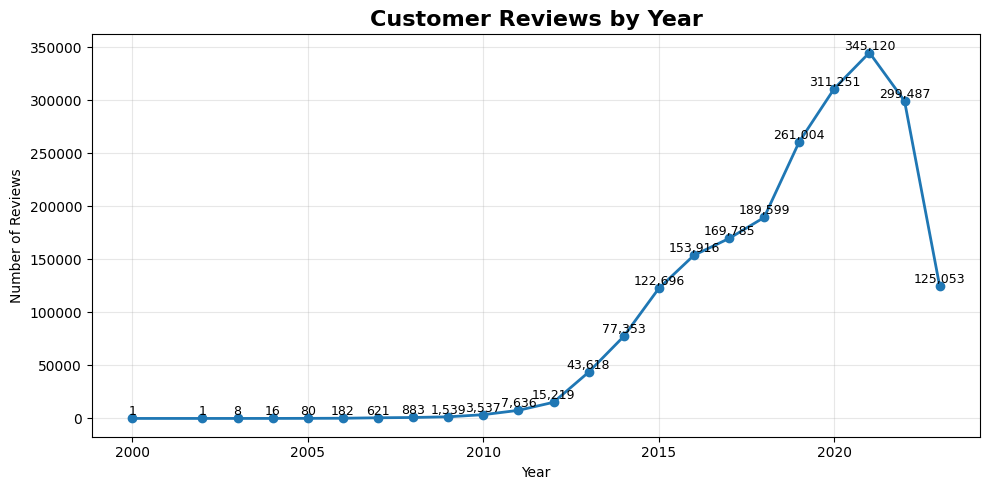

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(

    yearly_pd["year"],

    yearly_pd["count"],

    marker="o",

    linewidth=2

)

for x, y in zip(yearly_pd["year"], yearly_pd["count"]):

    plt.text(

        x,

        y,

        f"{y:,}",

        ha="center",

        va="bottom",

        fontsize=9

    )

plt.title(

    "Customer Reviews by Year",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Year")

plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Top 10 Most Reviewed Products
# ============================================================

top_products = (

    merged_df

    .groupBy("product_title")

    .count()

    .orderBy(F.desc("count"))

    .limit(10)

)

top_products_pd = top_products.toPandas()

top_products_pd

,product_title,count
0,12 Pack Keurig Filter Replacement by K&J - Com...,12027
1,iPartPlusMore Reusable Coffee Filters Compatib...,11620
2,Linda's Essentials Silicone Stove Gap Covers (...,8519
3,SAMSUNG Genuine Filters for Refrigerator Water...,7330
4,GE MWF Refrigerator Water Filter | Certified t...,7053
5,K&J 12-Pack of Cuisinart Compatible Replacemen...,6140
6,everydrop by Whirlpool Ice and Water Refrigera...,5896
7,Keurig My K-Cup Reusable Coffee Filter - Old M...,5803
8,KITCHEN BASICS 101 WB31M20 and WB31M19 Replace...,5668
9,Cuisinart SS-10P1 Premium 72-Ounce Single-Serv...,5401


/home/spark-8afd3136-f1de-47ac-aa28-f3/.ipykernel/323/command-5306760874671870-3154364989:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


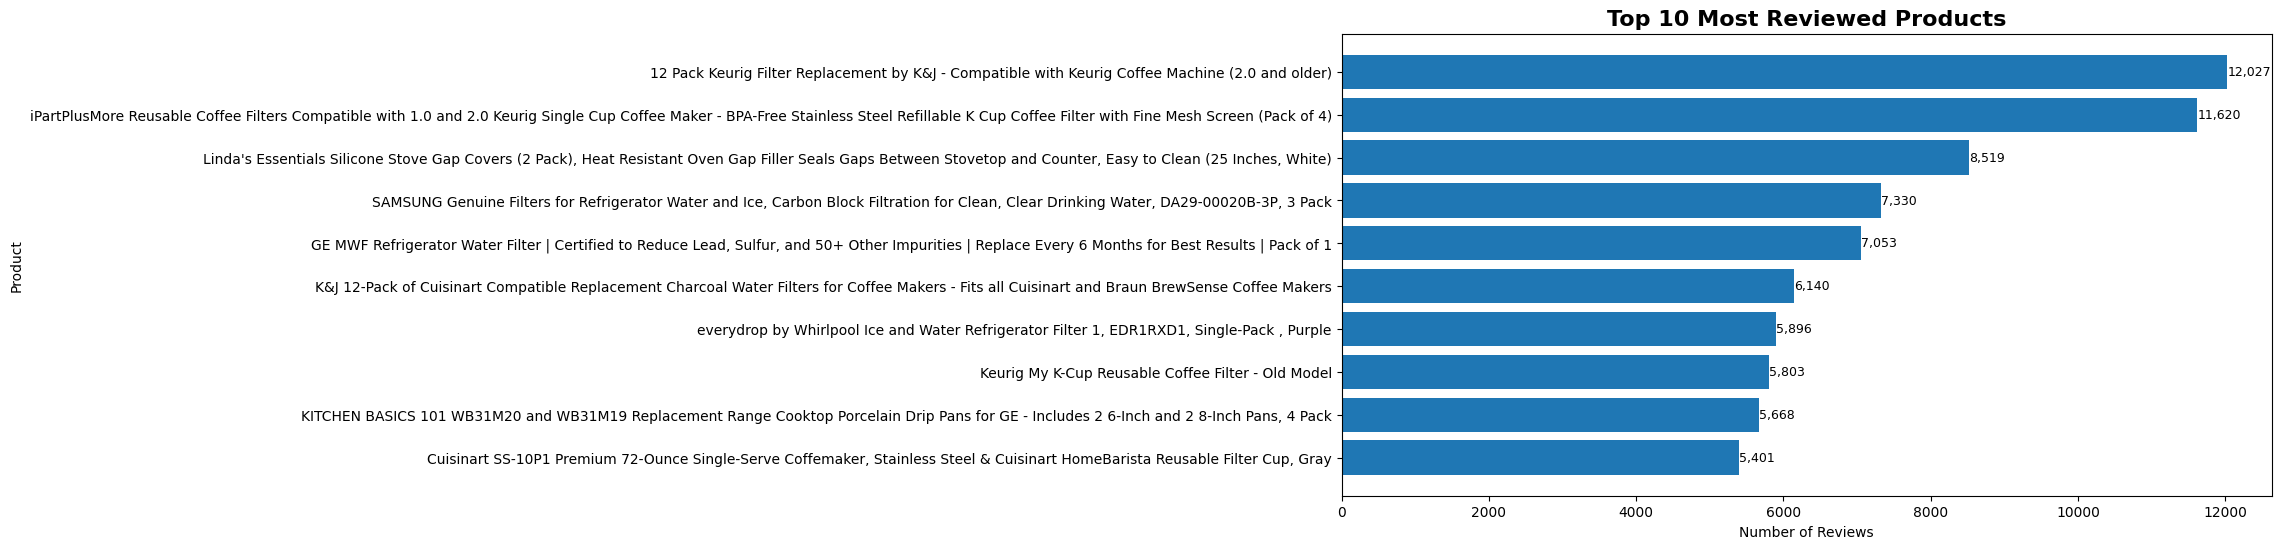

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

bars = plt.barh(

    top_products_pd["product_title"],

    top_products_pd["count"]

)

plt.gca().invert_yaxis()

for bar in bars:

    width = bar.get_width()

    plt.text(

        width,

        bar.get_y() + bar.get_height()/2,

        f"{int(width):,}",

        va="center",

        fontsize=9

    )

plt.title(

    "Top 10 Most Reviewed Products",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Number of Reviews")

plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Top 10 Stores by Review Count
# ============================================================

top_stores = (
    merged_df
    .filter(F.col("store").isNotNull())
    .groupBy("store")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
)

top_stores_pd = top_stores.toPandas()

top_stores_pd

,store,count
0,Whirlpool,137831
1,GE,80251
2,FRIGIDAIRE,62488
3,BlueStars,47740
4,WATERDROP,45617
5,SAMSUNG,40149
6,LG,36573
7,K&J,27320
8,Lifetime Appliance Parts,22423
9,ICEPURE,21495


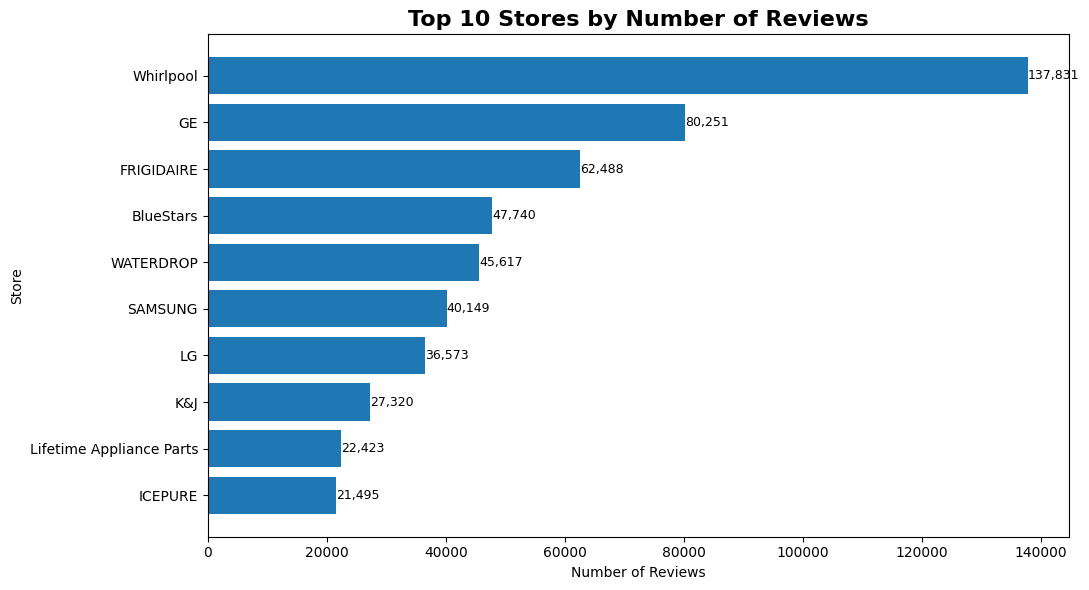

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11,6))

bars = plt.barh(
    top_stores_pd["store"],
    top_stores_pd["count"]
)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center",
        fontsize=9
    )

plt.title(
    "Top 10 Stores by Number of Reviews",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Reviews")
plt.ylabel("Store")

plt.tight_layout()
plt.show()

In [0]:
# ============================================================
# Price Distribution
# ============================================================

price_df = (
    merged_df
    .filter(F.col("price").isNotNull())
    .select("price")
)

price_pd = price_df.toPandas()

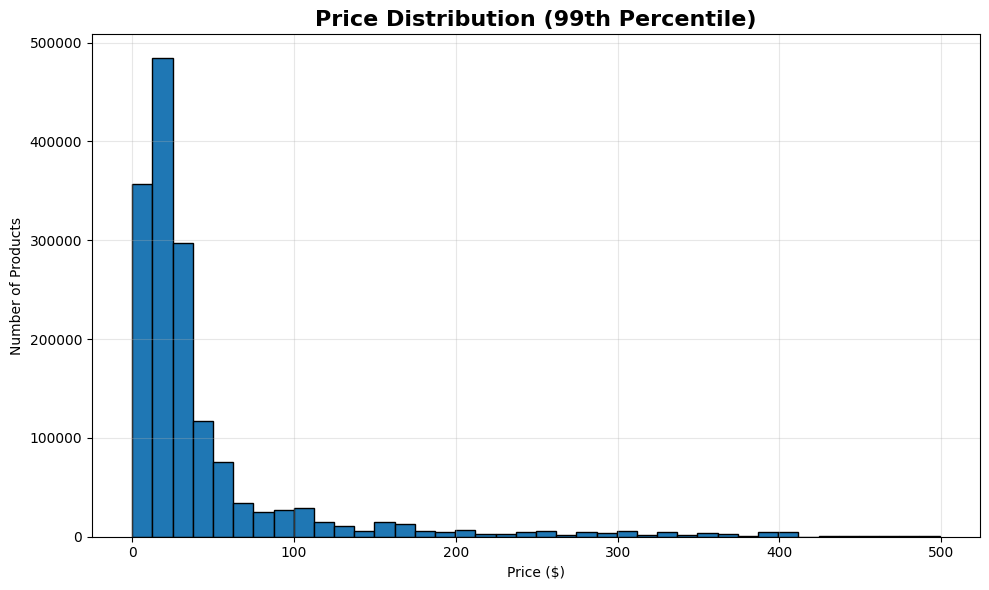

In [0]:
upper_limit = price_pd["price"].quantile(0.99)

filtered_price = price_pd[
    price_pd["price"] <= upper_limit
]

plt.figure(figsize=(10,6))

plt.hist(
    filtered_price["price"],
    bins=40,
    edgecolor="black"
)

plt.title(
    "Price Distribution (99th Percentile)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Price ($)")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
# ============================================================
# Price vs Average Rating
# ============================================================

price_rating = (
    merged_df
    .filter(
        (F.col("price").isNotNull()) &
        (F.col("average_rating").isNotNull())
    )
    .select("price", "average_rating")
)

price_rating_pd = price_rating.toPandas()

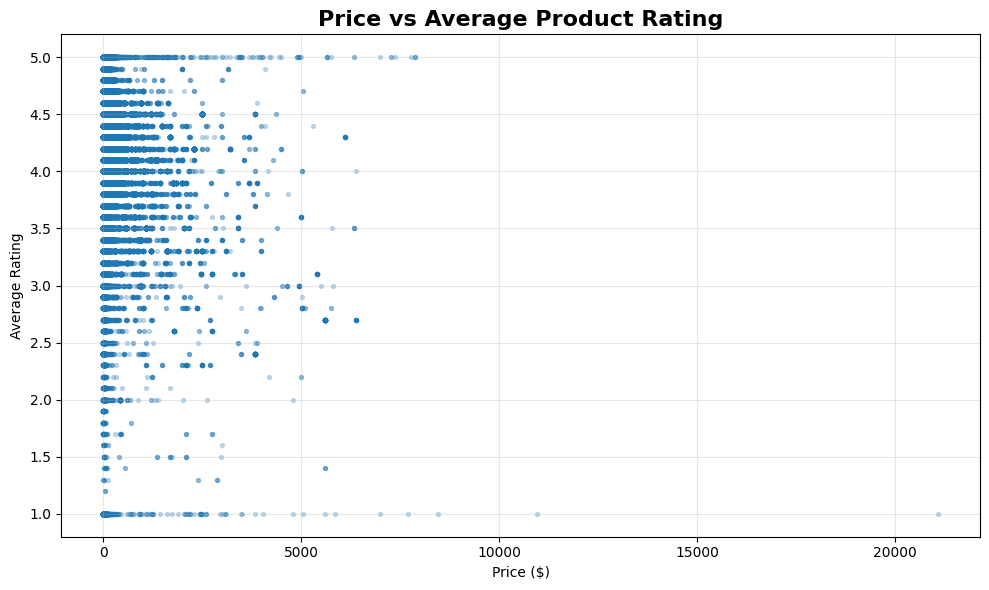

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    price_rating_pd["price"],
    price_rating_pd["average_rating"],
    alpha=0.25,
    s=8
)

plt.title(
    "Price vs Average Product Rating",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Price ($)")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

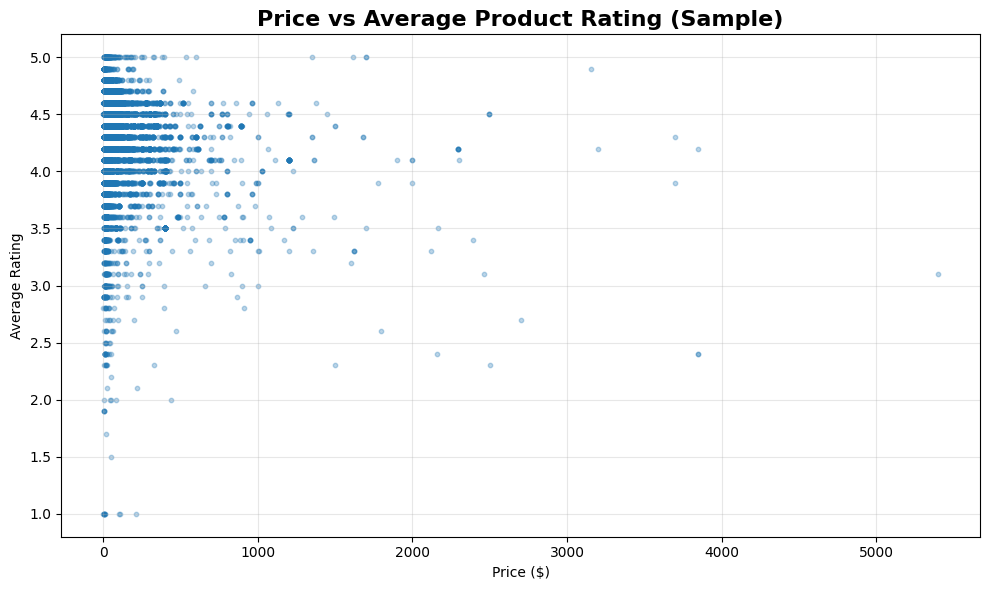

In [0]:
sample_price_rating = price_rating_pd.sample(
    n=30000,
    random_state=42
)

plt.figure(figsize=(10,6))

plt.scatter(
    sample_price_rating["price"],
    sample_price_rating["average_rating"],
    alpha=0.3,
    s=10
)

plt.title(
    "Price vs Average Product Rating (Sample)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Price ($)")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Review Trend by Year
# ============================================================

yearly_reviews = (
    merged_df
    .groupBy("year")
    .count()
    .orderBy("year")
)

yearly_reviews_pd = yearly_reviews.toPandas()

yearly_reviews_pd

,year,count
0,2000,1
1,2002,1
2,2003,8
3,2004,16
4,2005,80
5,2006,182
6,2007,621
7,2008,883
8,2009,1539
9,2010,3537


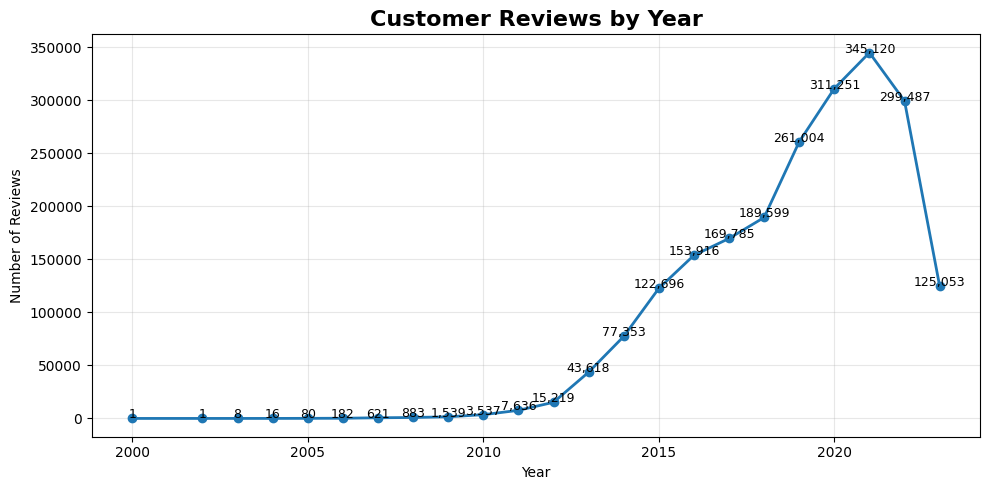

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    yearly_reviews_pd["year"],
    yearly_reviews_pd["count"],
    marker="o",
    linewidth=2
)

for x, y in zip(yearly_reviews_pd["year"], yearly_reviews_pd["count"]):
    plt.text(
        x,
        y,
        f"{y:,}",
        ha="center",
        fontsize=9
    )

plt.title(
    "Customer Reviews by Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
# ============================================================
# Monthly Review Trend
# ============================================================

monthly_reviews = (
    merged_df
    .groupBy("month")
    .count()
    .orderBy("month")
)

monthly_reviews_pd = monthly_reviews.toPandas()

monthly_reviews_pd

,month,count
0,1,215050
1,2,188555
2,3,203134
3,4,170174
4,5,161587
5,6,159861
6,7,179847
7,8,180236
8,9,158708
9,10,161622


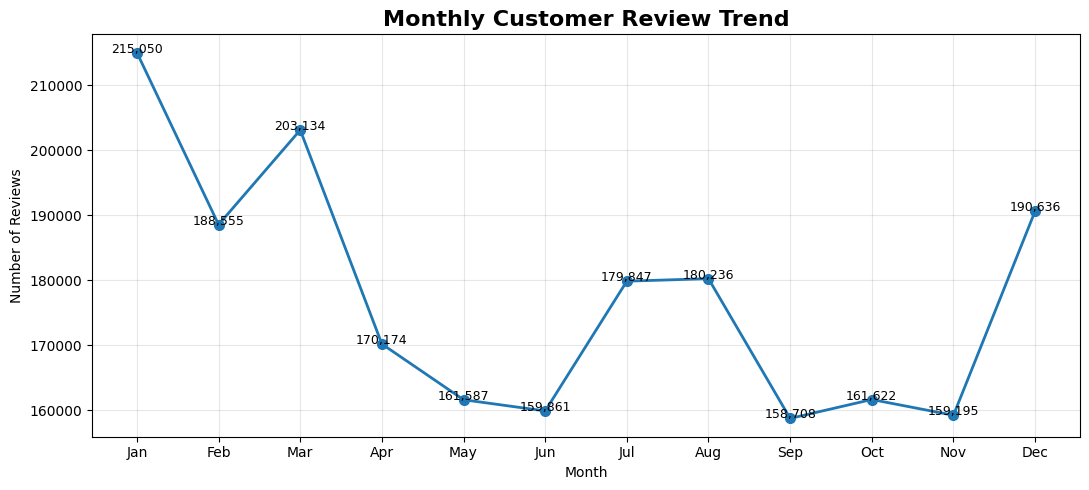

In [0]:
import matplotlib.pyplot as plt

month_names = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

plt.figure(figsize=(11,5))

plt.plot(
    month_names,
    monthly_reviews_pd["count"],
    marker="o",
    linewidth=2,
    markersize=7
)

for x, y in zip(month_names, monthly_reviews_pd["count"]):
    plt.text(
        x,
        y,
        f"{y:,}",
        ha="center",
        fontsize=9
    )

plt.title(
    "Monthly Customer Review Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

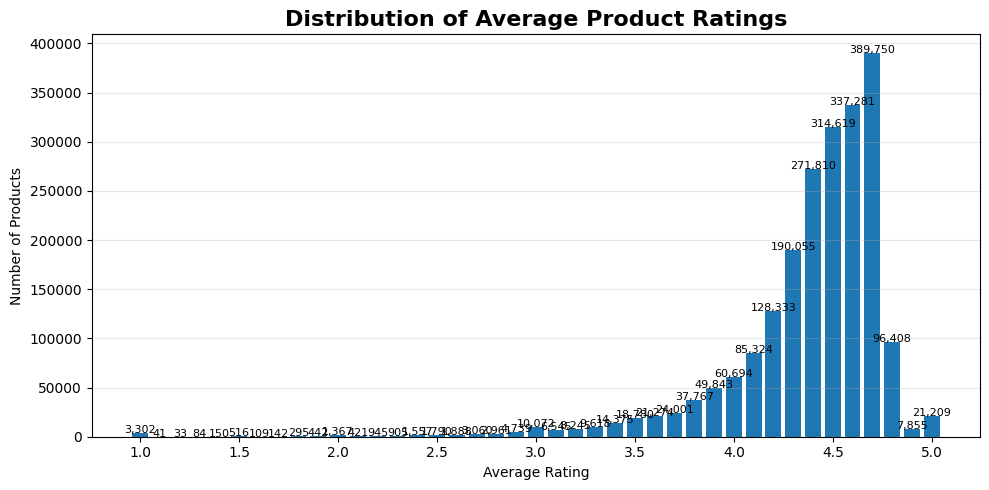

In [0]:
# ============================================================
# Average Product Rating Distribution
# ============================================================

rating_df = (
    merged_df
    .groupBy("average_rating")
    .count()
    .orderBy("average_rating")
)

rating_pd = rating_df.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(
    rating_pd["average_rating"],
    rating_pd["count"],
    width=0.08
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=8
    )

plt.title("Distribution of Average Product Ratings",fontsize=16,fontweight="bold")
plt.xlabel("Average Rating")
plt.ylabel("Number of Products")
plt.grid(axis="y",alpha=0.3)

plt.tight_layout()
plt.show()

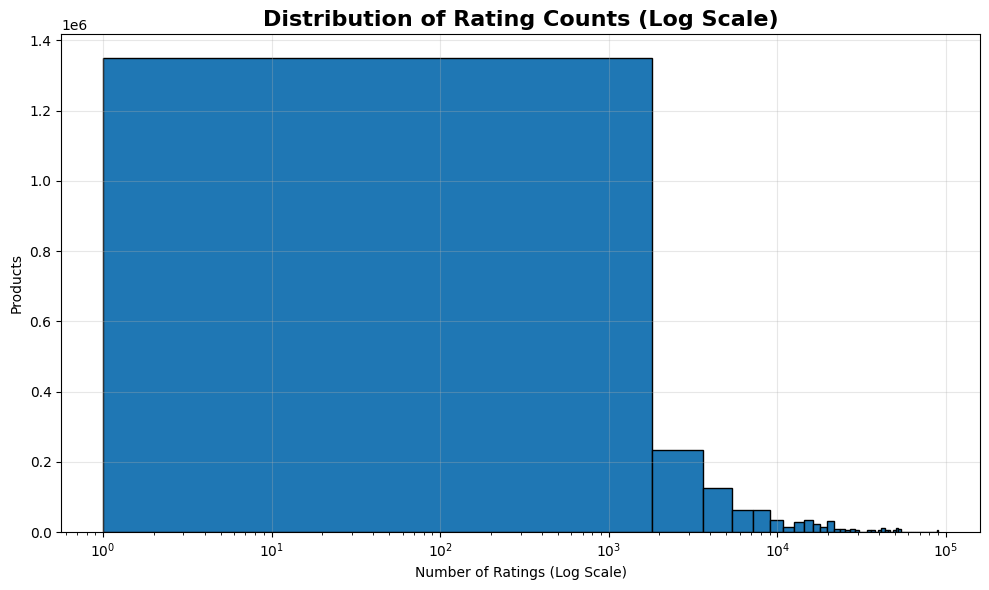

In [0]:
plt.figure(figsize=(10,6))

plt.hist(
    rating_number_pd["rating_number"],
    bins=50,
    edgecolor="black"
)

plt.xscale("log")

plt.title(
    "Distribution of Rating Counts (Log Scale)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Ratings (Log Scale)")
plt.ylabel("Products")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Helpful Vote Distribution
# ============================================================

helpful_pd = (
    merged_df
    .select("helpful_vote")
    .filter(F.col("helpful_vote").isNotNull())
    .toPandas()
)

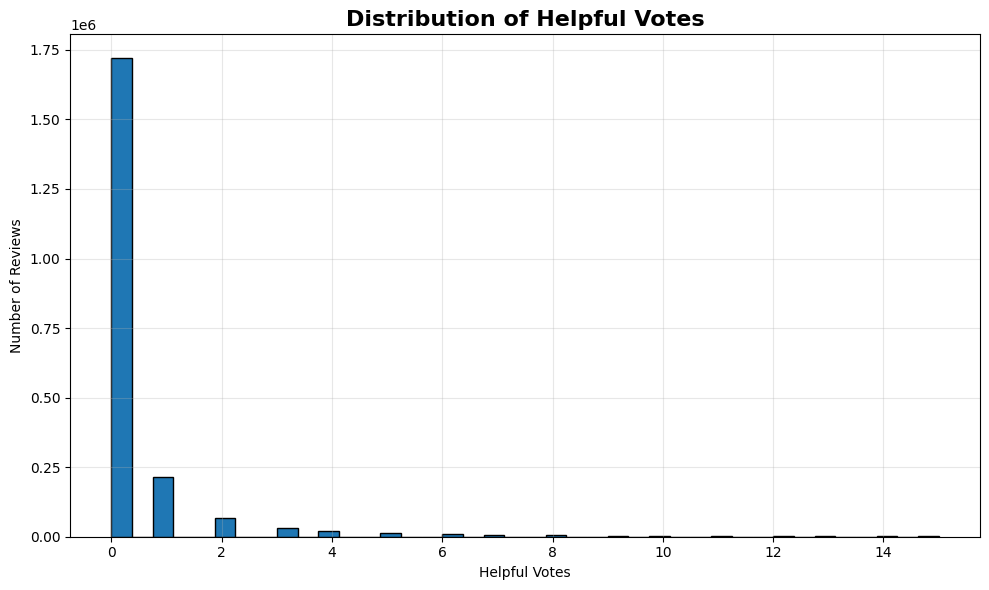

In [0]:
import matplotlib.pyplot as plt

upper = helpful_pd["helpful_vote"].quantile(0.99)

plt.figure(figsize=(10,6))

plt.hist(
    helpful_pd[
        helpful_pd["helpful_vote"] <= upper
    ]["helpful_vote"],
    bins=40,
    edgecolor="black"
)

plt.title(
    "Distribution of Helpful Votes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Helpful Votes")
plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
review_length_pd = (
    merged_df
    .select(
        F.length("review_text").alias("Review Length")
    )
    .toPandas()
)

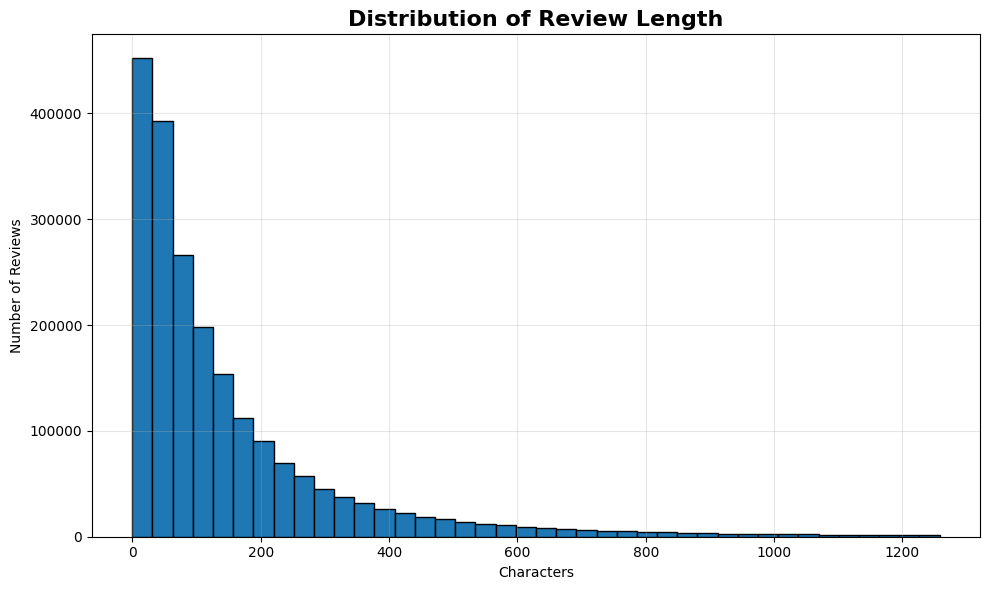

In [0]:
upper = review_length_pd["Review Length"].quantile(0.99)

plt.figure(figsize=(10,6))

plt.hist(
    review_length_pd[
        review_length_pd["Review Length"] <= upper
    ]["Review Length"],
    bins=40,
    edgecolor="black"
)

plt.title(
    "Distribution of Review Length",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Characters")
plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
corr_pd = (
    merged_df
    .select(
        "review_rating",
        "average_rating",
        "price",
        "rating_number",
        "helpful_vote"
    )
    .toPandas()
)

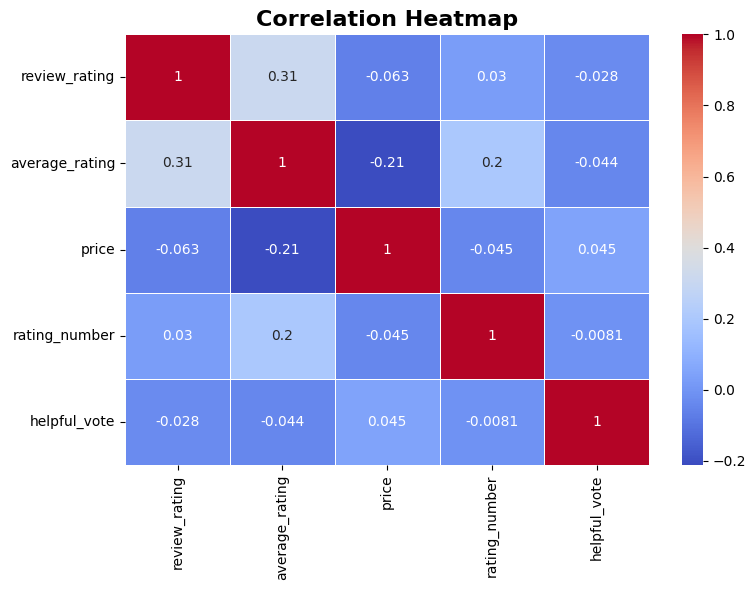

In [0]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_pd.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

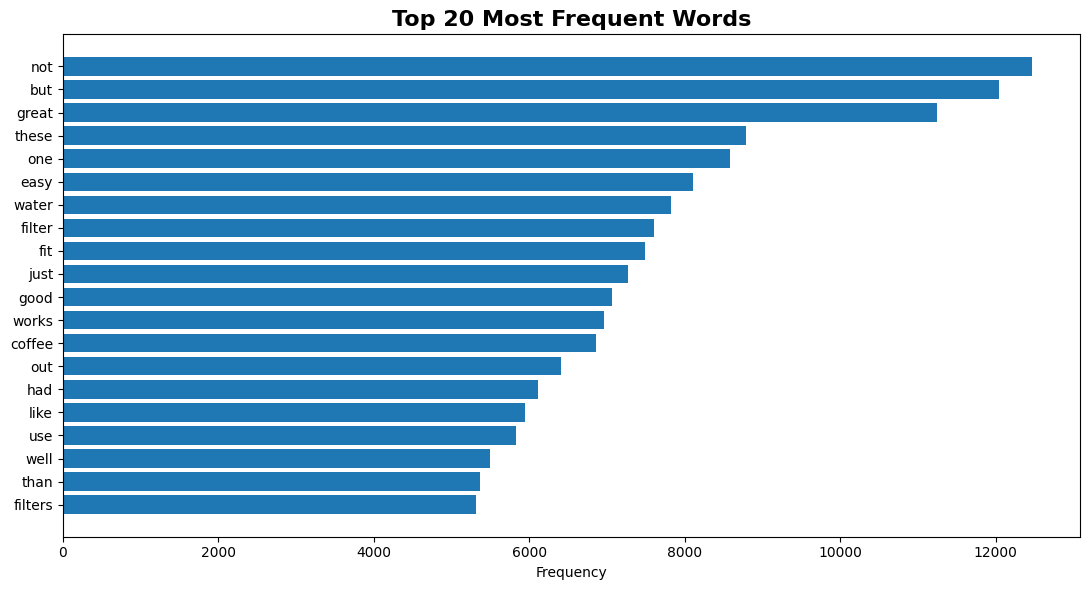

In [0]:
from collections import Counter
import re

text = " ".join(
    merged_df
    .select("review_text")
    .limit(50000)
    .toPandas()["review_text"]
    .fillna("")
)

words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

stop_words = {
    "the","and","a","to","is","it","of","for","in",
    "this","that","with","my","on","was","are","very",
    "have","has","i","you","we","they","be","as","an"
}

words = [w for w in words if w not in stop_words and len(w) > 2]

top_words = Counter(words).most_common(20)

word_df = pd.DataFrame(top_words, columns=["Word","Frequency"])

plt.figure(figsize=(11,6))

plt.barh(
    word_df["Word"],
    word_df["Frequency"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Most Frequent Words",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Frequency")

plt.tight_layout()

plt.show()

In [0]:
summary = {
    "Metric":[
        "Total Reviews",
        "Unique Products",
        "Unique Users",
        "Average Product Rating",
        "Average Review Rating",
        "Average Price",
        "Unique Stores"
    ],
    "Value":[
        merged_df.count(),
        merged_df.select("parent_asin").distinct().count(),
        merged_df.select("user_id").distinct().count(),
        round(
            merged_df.select(
                F.avg("average_rating")
            ).first()[0],
            2
        ),
        round(
            merged_df.select(
                F.avg("review_rating")
            ).first()[0],
            2
        ),
        round(
            merged_df.select(
                F.avg("price")
            ).first()[0],
            2
        ),
        merged_df.select("store").distinct().count()
    ]
}

display(
    spark.createDataFrame(pd.DataFrame(summary))
)

Metric,Value
Total Reviews,2128605.0
Unique Products,94319.0
Unique Users,1755732.0
Average Product Rating,4.39
Average Review Rating,4.22
Average Price,54.87
Unique Stores,13166.0


# Final Conclusion

## Key Findings

- The dataset contains over 2.1 million customer reviews across more than 94,000 appliance products.
- Customer ratings are highly positive, with 5-star reviews accounting for the majority of feedback.
- Most products are priced below $50, while premium products are comparatively rare.
- Customer engagement has increased steadily over the years, indicating growth in the Appliances category.
- A small number of products receive the majority of customer reviews, suggesting concentrated popularity.
- Review helpfulness is concentrated among a limited number of detailed reviews.
- Product price has only a weak relationship with customer ratings, indicating that quality and customer experience are stronger drivers of satisfaction.
- Review text analysis highlights common customer opinions that can support downstream NLP tasks such as sentiment analysis and summarization.

## Business Recommendations

- Prioritize highly reviewed products in recommendation systems.
- Investigate products with consistently low ratings for quality improvement.
- Use detailed reviews for sentiment analysis and keyword extraction.
- Focus promotional campaigns on top-performing stores and products.
- Leverage seasonal trends to optimize inventory and marketing strategies.